In [129]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import mlflow
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score,
                             roc_auc_score)
from itertools import product
from datetime import datetime
from torchinfo import summary

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── MLflow setup ──────────────────────────────────────────────────────────────
# Run `mlflow ui` in terminal to view results at http://127.0.0.1:5000
mlflow.set_tracking_uri("mlruns")          # saved locally in ./mlruns
mlflow.set_experiment("ugly-squat-classifier")  # name shown in the UI


Using device: mps


<Experiment: artifact_location=('/Users/jakob/Documents/Universitet/Deep '
 'ML/DeepLearning_Schoolwork/JakobProject/notebooks/mlruns/206493456605565532'), creation_time=1779121956325, experiment_id='206493456605565532', last_update_time=1779121956325, lifecycle_stage='active', name='ugly-squat-classifier', tags={}, trace_location=None, workspace='default'>

## Data preprocess

In [130]:
def load_and_reshape_all_files(data_dir, n_frames=30, n_features=66):
    """Load all CSV files and reshape them"""
    all_X = []
    all_y = []
    
    for csv_file in os.listdir(data_dir):
        if csv_file.endswith(".csv"):
            df = pd.read_csv(os.path.join(data_dir, csv_file))
            y = df["target"].values
            X_flat = df.drop(columns=["target"]).values
            
            # Reshape
            X = X_flat.reshape(-1, n_frames, n_features)
            
            all_X.append(X)
            all_y.append(y)
    
    # Concatenate all samples
    X_all = np.concatenate(all_X, axis=0)
    y_all = np.concatenate(all_y, axis=0)
    
    return X_all, y_all


def mirror_pose_data(X):
    """
    Mirror pose sequences by swapping left and right body parts.
    
    Args:
        X: numpy array of shape (n_samples, n_frames, 66)
    
    Returns:
        X_mirrored: mirrored version with same shape
    """ 
    # Define left-right pairs (5 features each: x, y, z, visibility, presence)
    left_pairs = [5, 10, 25, 35, 45, 55]  # Start indices of left features
    right_pairs = [15, 20, 30, 40, 50, 60]  # Start indices of right features
    
    X_mirrored = X.copy()
    
    for sample in range(X.shape[0]):
        for frame in range(X.shape[1]):
            # Swap each left-right pair
            for left_start, right_start in zip(left_pairs, right_pairs):
                # Swap all 5 features for this body part
                X_mirrored[sample, frame, left_start:left_start+5] = X[sample, frame, right_start:right_start+5]
                X_mirrored[sample, frame, right_start:right_start+5] = X[sample, frame, left_start:left_start+5]
    
    return X_mirrored

In [131]:
data_dir = "../../MainProject/data/mediapipe_ugly_recordings/"
X, y = load_and_reshape_all_files(data_dir, n_frames=30, n_features=66)
print(f"Total samples: {X.shape[0]}")
print(f"X shape: {X.shape}")  # (total_samples, 30, 66)

y[y == 1] = 0
y[(y == 2) | (y == 3)] = 1

# Then split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

X_train_mirrored = mirror_pose_data(X_train)  # Implement this based on feature swapping
y_train_mirrored = y_train.copy()

# 4. Combine original and mirrored training data
X_train_augmented = np.concatenate([X_train, X_train_mirrored], axis=0)
y_train = np.concatenate([y_train, y_train_mirrored], axis=0)

X_train = X_train_augmented.reshape(X_train_augmented.shape[0], 1, X_train_augmented.shape[1], X_train_augmented.shape[2])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1], X_test.shape[2])



scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape)



print(f"X_train shape for CNN: {X_train.shape}")  # (n, 1, 30, 66)
print(f"X_test shape for CNN: {X_test.shape}")    # (n, 1, 30, 66)

input_shape = (30, 66)  # (30, 66)
print(f"Input shape for model: {input_shape}")

Total samples: 203
X shape: (203, 30, 66)
X_train shape for CNN: (284, 1, 30, 66)
X_test shape for CNN: (61, 1, 30, 66)
Input shape for model: (30, 66)


## CNN Model

In [132]:
class SquatClassifierCNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.25):
        """
        Args:
            input_dim: tuple (frames, features) e.g., (30, 66)
        """
        super().__init__()
        frames, features = input_dim
        
        # Calculate output sizes after each layer
        # Input: (batch, 1, 30, 66)
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (batch, 32, 30, 66)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (batch, 32, 15, 33)
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (batch, 64, 15, 33)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (batch, 64, 7, 16)
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# (batch, 128, 7, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),                # (batch, 128, 1, 1)
            nn.Dropout2d(dropout_rate)
        )
        
        # Classifier (input is 128 from adaptive pooling)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # x shape: (batch, 1, 30, 66)
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)  # (batch, 128, 1, 1)
        x = x.view(x.size(0), -1)  # Flatten: (batch, 128)
        x = self.classifier(x)
        return x

def build_cnn_model(config, input_dim):
    """Build CNN model with given config"""
    return SquatClassifierCNN(
        input_dim=input_dim, 
        dropout_rate=config.get("dropout", 0.25)
    )


## Compute metrics and train model

In [133]:
# ── compute_metrics: fixed for 3-class ───────────────────────────────────────
def compute_metrics(y_true, probs):
    """
    y_true : 1-D int array of class indices (0, 1, 2)
    probs  : 2-D float array (n_samples, 3) — softmax probabilities
    """
    preds = np.argmax(probs, axis=1)
    return {
        "accuracy":  accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, average="macro", zero_division=0),
        "recall":    recall_score(y_true, preds, average="macro", zero_division=0),
        # ovr + macro is the standard multi-class AUC
        "auc":       roc_auc_score(y_true, probs, multi_class="ovr", average="macro"),
    }

def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn,
                    run_name=None):
    """
    y_train / y_val must be long tensors of shape (N,)  ← CrossEntropyLoss
    """
    device = x_train.device
    model  = model.to(device)

    optimizer        = optim.Adam(model.parameters(), lr=config["lr"])
    epochs           = config["epochs"]
    best_val_auc     = 0
    best_state       = None
    patience         = 200
    epochs_no_improve = 0
    history          = {"train_loss": [], "val_loss": [], "val_auc": []}

    with mlflow.start_run(run_name=run_name, nested=True):
        # Log hyperparameters once
        mlflow.log_params(config)

        for epoch in range(epochs):
            # ── train ──
            model.train()
            optimizer.zero_grad()
            logits     = model(x_train)
            train_loss = loss_fn(logits, y_train)   # y_train: (N,) long
            train_loss.backward()
            optimizer.step()

            # ── validate ──
            model.eval()
            with torch.no_grad():
                val_logits = model(x_val)
                val_loss   = loss_fn(val_logits, y_val)

            
                y_val_np = y_val.cpu().numpy()

                probs = torch.sigmoid(val_logits).squeeze(1).cpu().numpy()  # shape (N,)
         

                val_auc = roc_auc_score(
                    y_val_np, probs,
                    multi_class="ovr", average="macro"
                )

            history["train_loss"].append(train_loss.item())
            history["val_loss"].append(val_loss.item())
            history["val_auc"].append(val_auc)

            # Log per-epoch metrics to MLflow
            mlflow.log_metrics({
                "train_loss": train_loss.item(),
                "val_loss":   val_loss.item(),
                "val_auc":    val_auc,
            }, step=epoch)

            if val_auc > best_val_auc:
                best_val_auc      = val_auc
                best_state        = {k: v.clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(f"    Early stop at epoch {epoch}")
                break

        mlflow.log_metric("best_val_auc", best_val_auc)

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_auc, model, history


def cross_validate_model(config, X, y, loss_fn, input_dim, n_splits=10):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_auc_scores = []

    device = torch.device("cuda" if torch.cuda.is_available() else
                          "mps"  if torch.backends.mps.is_available() else
                          "cpu")
    print(f"  Using device: {device}")

    if len(X.shape) == 3:
        X = X.reshape(X.shape[0], 1, X.shape[1], X.shape[2])

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"  Fold {fold + 1}/{n_splits}...")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        X_train_t = torch.tensor(X_train_f, dtype=torch.float32).to(device)
        X_val_t   = torch.tensor(X_val_f,   dtype=torch.float32).to(device)

        # ✅ long + shape (N,)  — required by CrossEntropyLoss
        y_train_t = torch.tensor(y_train_f, dtype=torch.float32).unsqueeze(1).to(device)
        y_val_t   = torch.tensor(y_val_f,   dtype=torch.float32).unsqueeze(1).to(device)
        
        model = build_cnn_model(config, input_dim).to(device)

        val_auc, _, _ = train_one_model(
            model, config,
            X_train_t, y_train_t,
            X_val_t,   y_val_t,
            loss_fn,
            run_name=f"fold-{fold+1}"
        )
        fold_auc_scores.append(val_auc)

    return {
        "cv_mean_auc": np.mean(fold_auc_scores),
        "auc_std":     np.std(fold_auc_scores),
        "fold_scores": fold_auc_scores,
    }



## Save best model

In [134]:
def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")
    if not os.path.exists(path):
        return None
    with open(path, "r") as f:
        return json.load(f)

def save_champion_model(champion_dir, metadata_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters):
    torch.save(model.state_dict(), os.path.join(champion_dir, "champion_model.pt"))
    info = {
        "model_name": model_name,
        "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "auc": float(auc),
        "recall": float(recall),
        "precision": float(precision),
        "accuracy": float(accuracy),
        "hyperparameters": hyperparameters
    }
    with open(os.path.join(metadata_dir, "champion_info.json"), "w") as f:
        json.dump(info, f, indent=2)
    print("New champion model saved!")

def update_champion(metadata_dir, champion_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters):
    current = load_champion_info(metadata_dir)
    if current is None:
        print("No champion found --> saving first model")
        save_champion_model(champion_dir, metadata_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters)
    elif auc > current["auc"]:
        print(f"New model is better (auc {auc:.4f} > {current['auc']:.4f})")
        save_champion_model(champion_dir, metadata_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters)
    else:
        print(f"Model NOT better (auc {auc:.4f} <= {current['auc']:.4f})")

In [141]:
# ── Grid search with outer MLflow run ────────────────────────────────────────
param_grid = {"lr": [0.001], "dropout": [0.2], "epochs": [150]}
trial      = 0
best_auc   = 0
best_config = None

n_good = (y_train == 0).sum()
n_ugly = (y_train == 1).sum()
pos_weight = torch.tensor([n_good / n_ugly], dtype=torch.float32).to(device)  # ~4.5x

loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("Starting Grid Search...")
print("=" * 60)

for values in product(param_grid["lr"], param_grid["dropout"], param_grid["epochs"]):
    config = {"lr": values[0], "dropout": values[1], "epochs": values[2]}
    print(f"\nTrial {trial + 1}: {config}")

    # Each config gets its own parent run in the UI
    with mlflow.start_run(run_name=f"trial-{trial+1}_lr{config['lr']}_ep{config['epochs']}"):
        mlflow.log_params(config)

        results   = cross_validate_model(config, X_train, y_train, loss_func, input_shape)
        auc_score = results["cv_mean_auc"]

        mlflow.log_metrics({
            "cv_mean_auc": auc_score,
            "cv_auc_std":  results["auc_std"],
        })

    print(f"  CV mean AUC: {auc_score:.4f} +- {results['auc_std']:.4f}")

    if auc_score > best_auc:
        best_auc    = auc_score
        best_config = config
        print("  *** NEW BEST! ***")

    trial += 1

print("\n" + "=" * 60)
print(f"Best configuration: {best_config}")
print(f"Best cross-validation AUC: {best_auc:.4f}")
print("\nRun `mlflow ui` in your terminal to view results.")


Starting Grid Search...

Trial 1: {'lr': 0.001, 'dropout': 0.2, 'epochs': 150}
  Using device: mps
  Fold 1/10...
  Fold 2/10...
  Fold 3/10...
  Fold 4/10...
  Fold 5/10...
  Fold 6/10...
  Fold 7/10...
  Fold 8/10...
  Fold 9/10...
  Fold 10/10...
  CV mean AUC: 1.0000 +- 0.0000
  *** NEW BEST! ***

Best configuration: {'lr': 0.001, 'dropout': 0.2, 'epochs': 150}
Best cross-validation AUC: 1.0000

Run `mlflow ui` in your terminal to view results.


Final model validation AUC: 1.0000
Layer (type:depth-idx)                   Output Shape              Param #
SquatClassifierCNN                       [1, 1]                    --
├─Sequential: 1-1                        [1, 32, 15, 33]           --
│    └─Conv2d: 2-1                       [1, 32, 30, 66]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 30, 66]           64
│    └─ReLU: 2-3                         [1, 32, 30, 66]           --
│    └─MaxPool2d: 2-4                    [1, 32, 15, 33]           --
│    └─Dropout2d: 2-5                    [1, 32, 15, 33]           --
├─Sequential: 1-2                        [1, 64, 7, 16]            --
│    └─Conv2d: 2-6                       [1, 64, 15, 33]           18,496
│    └─BatchNorm2d: 2-7                  [1, 64, 15, 33]           128
│    └─ReLU: 2-8                         [1, 64, 15, 33]           --
│    └─MaxPool2d: 2-9                    [1, 64, 7, 16]            --
│    └─Dropout2d: 2-10                   [1,

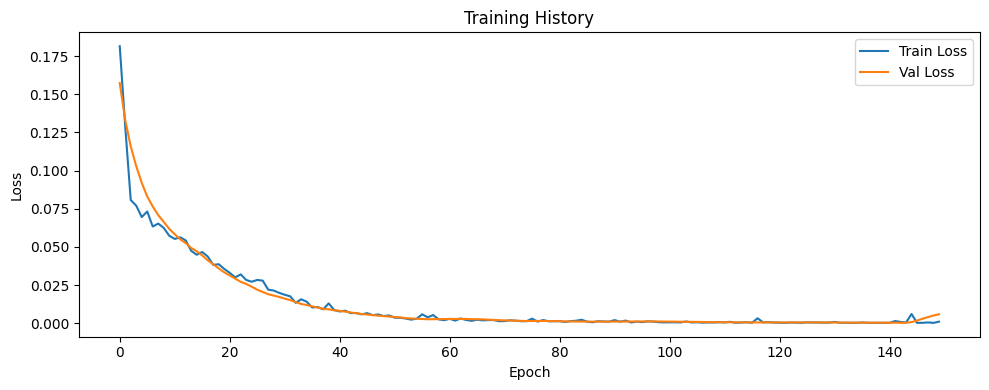

In [142]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_test,   dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_val_t   = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

final_model = build_cnn_model(best_config, input_shape)
                                                        
with mlflow.start_run(run_name="final_model"):
    val_auc, final_model, history = train_one_model(
        final_model, best_config, X_train_t, y_train_t, X_val_t, y_val_t,
        loss_func, run_name="final_model_inner"
    )

print(f"Final model validation AUC: {val_auc:.4f}")
print(summary(final_model, input_size=(1, 1, input_shape[0], input_shape[1])))

plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training History")
plt.tight_layout()
plt.show()


TEST SET EVALUATION
Test AUC:       1.0000
Accuracy:       0.9672
Precision:      1.0000
Recall:         0.9600


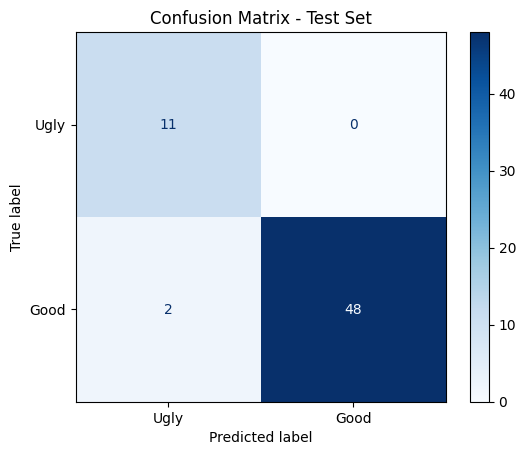

In [148]:
# Convert to tensors correctly

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test, dtype=torch.long).to(device)

# Sedan i evaluate-blocket:


final_model.eval().to(device)

with torch.no_grad():
    logits = final_model(X_test_t)
    y_test_np = y_test_t.cpu().numpy()
 
    probs     = torch.sigmoid(logits).squeeze(1).cpu().numpy()  # shape (N,)
    y_pred_np = (probs >= 0.5).astype(int)
    
    accuracy = accuracy_score(y_test_np, y_pred_np)
    precision = precision_score(y_test_np, y_pred_np)
    recall = recall_score(y_test_np, y_pred_np)
    
    # For AUC in multi-class, you need probabilities

    auc       = roc_auc_score(y_test_np, probs)  # ingen multi_class för binär
    


print("\n" + "=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
print(f"Test AUC:       {auc:.4f}")
print(f"Accuracy:       {accuracy:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")

# Confusion matrix with your class labels
cm = confusion_matrix(y_test_np, y_pred_np)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ugly", "Good"])  # Adjust labels
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()